# Notebook 08 — Tourism Demand Forecasting under IMF Macroeconomic Scenarios

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub — Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-04

---

## Purpose

This is the applied, market-oriented component of the thesis. The previous notebooks established **what the best demand forecasting model is** and validated its accuracy. This notebook turns that into a **forward-looking decision support tool**: given the IMF's macroeconomic projections under alternative scenarios, what does the demand for Polish foreign tourism look like in 2025-2026? It will also be useful to make the prediction for upcoming years, based on historical data + predictions.

## Pipeline structure

The notebook is organised around three concrete deliverables:

1. **A demand forecast under three macroeconomic scenarios** (Trend-wise / Optimistic / Pessimist), built by feeding the LSTM-1step V2 model from NB07 with WEO-derived GDP paths. The forecast horizon is February 2025 to November 2026 (22 months), arriving precisely at the gap where the historical panel runs out of macroeconomic data and continuing into the prospective year of interest.

2. **A sanity check using the elasticity-income coefficient from the literature**: applying the average tourism income elasticity of 2.0 reported by Peng et al. (2015) directly to the WEO GDP path, as an independent benchmark of the LSTM forecast. If both methods agree in order of magnitude, the LSTM result is robust; if they disagree wildly, something is wrong with one of the two.

3. **A causal analysis of COVID** with the Bayesian CausalImpact framework, providing a credibility-bounded estimate of the cumulative overnight stays "lost" during 2020-2025 versus the counterfactual of no shock.

## Important methodological choices

**No Stage 1 capacity model:** Earlier drafts of this notebook included a separate XGBoost capacity model that mapped macroeconomic indicators to seat supply (`seats`). On reflection, this was redundant for the operational use-case: airlines plan their own capacity 6-12 months in advance and do not need our model to predict it. What they need is the demand response *given* their planned capacity. We therefore project `seats` forward using a simple continuity rule (last observed year + average annual growth) and use the LSTM exclusively as a demand model.

**Scenario shifts of ±2pp on origin-market GDP:** The IMF WEO publishes baseline projections; alternative scenarios are constructed by adjusting the year-on-year GDP growth rate of the origin markets by ±2 percentage points. We use ±2pp rather than ±1pp because the demand model's elasticity to macroeconomic features is moderate (the model was deliberately designed in NB06-07 to avoid macro features dominating the prediction), so a ±1pp shift produces visually negligible differences. ±2pp is still within the range of historical macroeconomic volatility (the 2008-2009 crisis represented roughly ±4pp on annual GDP) and produces interpretable scenario differentials.

**Scale normalisation between panel and WEO:** The historical panel encodes `gdp_pc_origins_wavg` in a unit different from USD/year (likely a derived unit from the Eurostat source). The WEO publishes USD/year. We compute the empirical conversion factor at the join point and apply it consistently throughout the forecast window.

In [48]:
print("hello world")

hello world


---

## 0. Environment & Configuration

In [49]:
import pandas as pd
import numpy as np
import os
import warnings
import random

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 2004
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'font.size': 10, 'legend.fontsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'savefig.bbox': 'tight', 'savefig.dpi': 200, 'savefig.facecolor': 'white',
})

SCENARIO_COLORS = {
    'Trend-wise': '#3498db',
    'Optimistic':  '#2ecc71',
    'Pessimist':  '#e74c3c',
}

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

DATA_RAW       = os.path.join('..', 'data', 'raw')
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
FIG_DIR        = os.path.join('..', 'figures', 'scenarios')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')

print('Environment ready.')

Environment ready.


---

## 1. Load Master Panel

In [50]:
panel = pd.read_csv(
    os.path.join(DATA_PROCESSED, 'master_panel_monthly.csv'),
    index_col=0, parse_dates=True
)
panel.index.name = 'date'
panel['nights_yoy'] = panel['nights'] / panel['nights'].shift(12)

TARGET_LEVEL = 'nights'
TARGET_YOY   = 'nights_yoy'

print(f'Panel: {panel.shape[0]} rows x {panel.shape[1]} cols')
print(f'Period: {panel.index[0]:%Y-%m} -> {panel.index[-1]:%Y-%m}')

# Identify the gap: where do macroeconomic features run out?
last_macro_date = panel['gdp_pc_origins_wavg'].dropna().index[-1]
first_gap_date  = last_macro_date + pd.DateOffset(months=1)
print(f'\nLast month with macro observations: {last_macro_date:%Y-%m}')
print(f'Gap starts at:                       {first_gap_date:%Y-%m}')
print(f'Gap ends at:                         {panel.index[-1]:%Y-%m}')

Panel: 179 rows x 39 cols
Period: 2011-01 -> 2025-11

Last month with macro observations: 2025-01
Gap starts at:                       2025-02
Gap ends at:                         2025-11


---

## 2. Load IMF WEO Data

The IMF WEO file (`WEO_Data_all.xls`) is tab-separated text in UTF-16 LE encoding, despite the .xls extension. We load it directly with that specification.

In [51]:
WEO_PATH = os.path.join(DATA_RAW, 'economic', 'WEO_Data_all.xls')
weo_raw = pd.read_csv(WEO_PATH, sep='\t', encoding='utf-16-le', low_memory=False)
print(f'WEO raw shape: {weo_raw.shape}')
print(f'Sample columns: {list(weo_raw.columns[:10])}')

WEO raw shape: (8625, 62)
Sample columns: ['WEO Country Code', 'ISO', 'WEO Subject Code', 'Country', 'Subject Descriptor', 'Subject Notes', 'Units', 'Scale', 'Country/Series-specific Notes', '1980']


In [52]:
# Filter for the 9 source markets + Poland, and the indicators we need
COUNTRIES_ISO = ['POL', 'ESP', 'DEU', 'GBR', 'FRA', 'ITA',
                  'NLD', 'SWE', 'AUT', 'CZE']
WEO_INDICATORS = ['NGDP_RPCH', 'NGDPDPC', 'PCPIPCH', 'LP', 'LUR']

weo_filt = weo_raw[
    weo_raw['ISO'].isin(COUNTRIES_ISO) &
    weo_raw['WEO Subject Code'].isin(WEO_INDICATORS)
].copy()

year_cols = [str(y) for y in range(1980, 2031) if str(y) in weo_filt.columns]
weo_long = weo_filt[['ISO', 'WEO Subject Code'] + year_cols].melt(
    id_vars=['ISO', 'WEO Subject Code'], var_name='year', value_name='value')
weo_long['year'] = weo_long['year'].astype(int)
weo_long['value'] = (
    weo_long['value'].astype(str).str.strip()
    .str.replace(',', '', regex=False)
    .replace({'n/a': np.nan, '--': np.nan, '': np.nan})
)
weo_long['value'] = pd.to_numeric(weo_long['value'], errors='coerce')
weo_long = weo_long.rename(columns={'WEO Subject Code': 'indicator'})
weo_wide = weo_long.pivot_table(
    index=['ISO', 'year'], columns='indicator', values='value'
).reset_index()
weo_wide.columns.name = None

print(f'WEO filtered + reshaped: {weo_wide.shape}')
print(f'Countries: {sorted(weo_wide["ISO"].unique())}')
print(f'Indicators: {sorted([c for c in weo_wide.columns if c not in ["ISO", "year"]])}')

WEO filtered + reshaped: (495, 7)
Countries: ['AUT', 'CZE', 'DEU', 'ESP', 'FRA', 'GBR', 'ITA', 'NLD', 'POL', 'SWE']
Indicators: ['LP', 'LUR', 'NGDPDPC', 'NGDP_RPCH', 'PCPIPCH']


---

## 3. Compute Weighted Aggregates and Normalise Scales

The WEO publishes data per country. To match the panel's `gdp_pc_origins_wavg` (a weighted average of origin-market values), we apply the same passenger-flow weights as in NB04 and aggregate the WEO values across the nine source markets.

We then compute the **scale conversion factor** between the panel's encoding of `gdp_pc_origins_wavg` (which appears to be in a unit derived from Eurostat source data, with a value of ~8,300) and the WEO's NGDPDPC (in USD/year, with a weighted value of ~48,000 in 2024). The factor is computed empirically at the join point so that the forecast extension is continuous with the historical observations.

In [53]:
# Source-market weights from avia_paoc (matching NB04)
SOURCE_MARKET_WEIGHTS = {
    'ESP': 0.198, 'DEU': 0.195, 'GBR': 0.188, 'FRA': 0.144,
    'ITA': 0.135, 'NLD': 0.066, 'SWE': 0.032, 'AUT': 0.029,
    'CZE': 0.014,
}
weight_total = sum(SOURCE_MARKET_WEIGHTS.values())
# Normalise to exactly 1.0
SOURCE_MARKET_WEIGHTS = {k: v / weight_total for k, v in SOURCE_MARKET_WEIGHTS.items()}
print(f'Source-market weights (normalised, sum=1.000):')
for iso, w in SOURCE_MARKET_WEIGHTS.items():
    print(f'  {iso}: {w:.4f}')

Source-market weights (normalised, sum=1.000):
  ESP: 0.1978
  DEU: 0.1948
  GBR: 0.1878
  FRA: 0.1439
  ITA: 0.1349
  NLD: 0.0659
  SWE: 0.0320
  AUT: 0.0290
  CZE: 0.0140


In [54]:
def weighted_origins_annual(indicator):
    """Return a Series of weighted origin-market annual values for a WEO indicator."""
    out = None
    for iso, w in SOURCE_MARKET_WEIGHTS.items():
        country_series = weo_wide[weo_wide['ISO'] == iso].set_index('year')[indicator]
        weighted = country_series * w
        if out is None:
            out = weighted
        else:
            common = out.index.intersection(weighted.index)
            out = out.loc[common] + weighted.loc[common]
    return out

# Weighted origin GDP per capita (USD/year), annual
gdp_pc_orig_annual = weighted_origins_annual('NGDPDPC')
print('Weighted origin GDP per capita (annual, USD/year):')
print(gdp_pc_orig_annual.loc[2020:2030].round(0))

Weighted origin GDP per capita (annual, USD/year):
year
2020    39059.0
2021    44205.0
2022    42650.0
2023    46104.0
2024    48055.0
2025    49296.0
2026    51092.0
2027    52775.0
2028    54558.0
2029    56441.0
2030    58388.0
Name: NGDPDPC, dtype: float64


In [55]:
# COMPUTE SCALE FACTOR PANEL <-> WEO ---
# At the last month of the panel with macro data (2025-01), the panel value
# corresponds to the WEO value at the appropriate annual interpolation point.
# We use the 2024 WEO annual value (the year of the last macro observation)
# as anchor.
panel_anchor_value = panel.loc[last_macro_date, 'gdp_pc_origins_wavg']
weo_anchor_value   = gdp_pc_orig_annual.loc[2024]

# Refine: take the WEO interpolated value at last_macro_date specifically
# Linear interpolation between 2024 and 2025 anchored at July of each year
weo_2024 = gdp_pc_orig_annual.loc[2024]
weo_2025 = gdp_pc_orig_annual.loc[2025]
# last_macro_date is 2025-01; halfway between July-2024 and July-2025 = January-2025 is exactly mid-point
fraction = ((last_macro_date - pd.Timestamp('2024-07-01')).days /
            (pd.Timestamp('2025-07-01') - pd.Timestamp('2024-07-01')).days)
weo_interp_at_anchor = weo_2024 + (weo_2025 - weo_2024) * fraction

SCALE_FACTOR_GDP = panel_anchor_value / weo_interp_at_anchor
print(f'Panel value at {last_macro_date:%Y-%m}:        {panel_anchor_value:>10,.2f}')
print(f'WEO interpolated at same date (USD/year):  {weo_interp_at_anchor:>10,.2f}')
print(f'\nScale factor (panel = WEO * SCALE_FACTOR): {SCALE_FACTOR_GDP:.6f}')
print(f'(reciprocal — 1 panel unit = {1/SCALE_FACTOR_GDP:.4f} USD/year)')

Panel value at 2025-01:          8,322.87
WEO interpolated at same date (USD/year):   48,680.53

Scale factor (panel = WEO * SCALE_FACTOR): 0.170969
(reciprocal — 1 panel unit = 5.8490 USD/year)


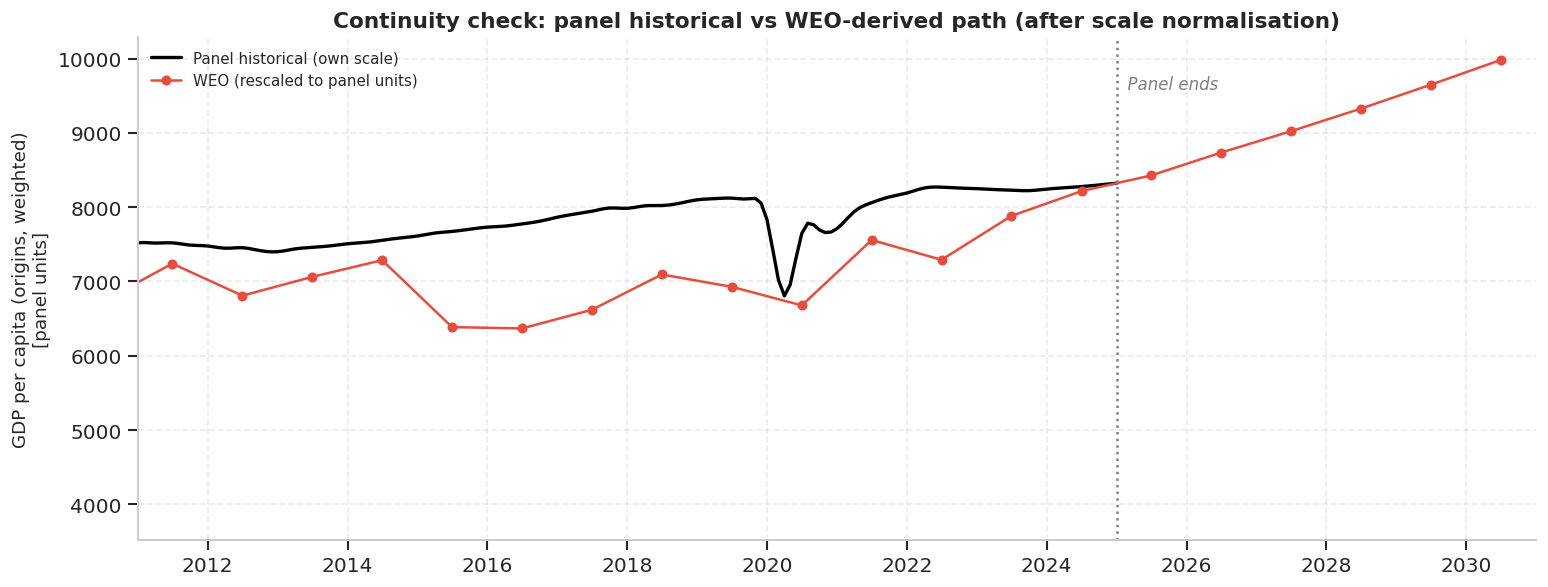

In [56]:
# Sanity check: extrapolate the panel forward using WEO and verify continuity
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(panel.index, panel['gdp_pc_origins_wavg'], color='black', lw=2,
        label='Panel historical (own scale)')

# Build a WEO-derived series in panel scale
weo_in_panel_scale = gdp_pc_orig_annual * SCALE_FACTOR_GDP
annual_dates = [pd.Timestamp(year=y, month=7, day=1) for y in weo_in_panel_scale.index]
ax.plot(annual_dates, weo_in_panel_scale.values, 'o-',
        color='#e74c3c', lw=1.5, ms=5,
        label='WEO (rescaled to panel units)')

ax.axvline(last_macro_date, color='gray', ls=':', lw=1.5)
ax.text(last_macro_date, ax.get_ylim()[1]*0.95, '  Panel ends',
        ha='left', va='top', color='gray', fontstyle='italic')
ax.set_title('Continuity check: panel historical vs WEO-derived path '
             '(after scale normalisation)',
             fontweight='bold')
ax.set_ylabel('GDP per capita (origins, weighted)\n[panel units]')
ax.legend(loc='upper left')
ax.set_xlim(pd.Timestamp('2011-01-01'), pd.Timestamp('2030-12-31'))
plt.tight_layout()
savefig('08_00_scale_continuity_check.png')
plt.show()

---

## 4. Build the Three Scenarios

Scenarios are built by adjusting the WEO baseline annual GDP growth path of the origin markets:

- **Trend-wise (Tendencial):** WEO baseline NGDPDPC unchanged.
- **Optimistic (Optimista):** annual GDP growth shifted by +2pp relative to baseline, applied compoundly from 2026 onwards.
- **Pessimist (Pesimista):** annual GDP growth shifted by -2pp relative to baseline, applied compoundly from 2026 onwards.

We work in panel units throughout the forecast. The annual values are interpolated linearly to monthly frequency. For the population, we apply WEO projections directly (population trajectories are essentially identical across scenarios because demographic dynamics are not GDP-sensitive on this horizon).

In [57]:
FORECAST_START = first_gap_date          # 2025-02
FORECAST_END   = pd.Timestamp('2026-11-01')  # last forecast month
FORECAST_INDEX = pd.date_range(FORECAST_START, FORECAST_END, freq='MS')

print(f'Forecast horizon: {FORECAST_START:%Y-%m} -> {FORECAST_END:%Y-%m}')
print(f'Number of forecast months: {len(FORECAST_INDEX)}')
print(f'  - Of which already observed (panel has nights but no macro): '
      f'{(FORECAST_INDEX <= panel.index[-1]).sum()}')
print(f'  - Of which fully prospective (no nights observed yet): '
      f'{(FORECAST_INDEX > panel.index[-1]).sum()}')

Forecast horizon: 2025-02 -> 2026-11
Number of forecast months: 22
  - Of which already observed (panel has nights but no macro): 10
  - Of which fully prospective (no nights observed yet): 12


In [58]:
def annual_to_monthly_linear(annual_series, start_month=7):
    """Convert annual WEO data to monthly via linear interpolation, anchored at
    July 1 of each year (mid-year as proxy for the annual average)."""
    s = annual_series.dropna()
    if len(s) == 0:
        return pd.Series(dtype=float)
    anchor_dates = [pd.Timestamp(year=int(y), month=start_month, day=1)
                    for y in s.index]
    anchor_series = pd.Series(s.values, index=anchor_dates)
    monthly_index = pd.date_range(
        start=anchor_series.index[0], end=anchor_series.index[-1], freq='MS')
    return anchor_series.reindex(monthly_index).interpolate(method='linear')


def build_scenario_gdp_path(shift_pp, name):
    """Build a monthly path of weighted-origin GDP per capita under a scenario.
    
    The shift is applied to the WEO's growth path: each year's GDP growth
    is shifted by `shift_pp` percentage points starting in 2026, and the
    path is rebuilt by compounding from the 2025 anchor.
    """
    # WEO real GDP growth (annual %) for origins, weighted
    growth_orig = weighted_origins_annual('NGDP_RPCH')  # annual %
    
    # Anchor: 2025 WEO value (already projected, baseline)
    anchor_year  = 2025
    anchor_value = gdp_pc_orig_annual.loc[anchor_year]
    
    # Build adjusted annual values
    annual_values = {anchor_year: anchor_value}
    current_value = anchor_value
    for y in range(anchor_year + 1, 2031):
        baseline_growth = growth_orig.loc[y] if y in growth_orig.index else 2.0
        adjusted_growth = baseline_growth + shift_pp
        current_value = current_value * (1 + adjusted_growth / 100)
        annual_values[y] = current_value
    
    # Also keep historical values up to anchor_year for interpolation
    for y in range(2020, anchor_year):
        if y in gdp_pc_orig_annual.index:
            annual_values[y] = gdp_pc_orig_annual.loc[y]
    
    annual_series = pd.Series(annual_values).sort_index()
    
    # Interpolate to monthly
    monthly_usd = annual_to_monthly_linear(annual_series)
    
    # Convert to panel scale
    monthly_panel_scale = monthly_usd * SCALE_FACTOR_GDP
    
    return monthly_panel_scale


scenario_gdp_paths = {
    'Trend-wise': build_scenario_gdp_path(0.0,  'Trend-wise'),
    'Optimistic':  build_scenario_gdp_path(+2.0, 'Optimistic'),
    'Pessimist':  build_scenario_gdp_path(-2.0, 'Pessimist'),
}

# Sanity check: differences at end of horizon
print('GDP path values (panel units) at end of forecast horizon:')
for sname, spath in scenario_gdp_paths.items():
    val = spath.loc[FORECAST_END]
    print(f'  {sname:<12s}: {val:>10,.2f}  (USD equivalent: {val/SCALE_FACTOR_GDP:>10,.0f})')

GDP path values (panel units) at end of forecast horizon:
  Trend-wise  :   8,574.73  (USD equivalent:     50,154)
  Optimistic  :   8,802.10  (USD equivalent:     51,484)
  Pessimist   :   8,349.61  (USD equivalent:     48,837)


In [59]:
# Population path: same for all scenarios (demographic projections)
pop_orig_annual = weighted_origins_annual('LP')  # in millions
pop_orig_monthly_millions = annual_to_monthly_linear(pop_orig_annual)
pop_orig_monthly_persons  = pop_orig_monthly_millions * 1e6

# HICP ratio path: forward-fill from last panel observation, evolved by inflation differential
infl_pol_annual = weo_wide[weo_wide['ISO']=='POL'].set_index('year')['PCPIPCH']
infl_orig_annual = weighted_origins_annual('PCPIPCH')
infl_diff_annual = infl_pol_annual - infl_orig_annual
infl_diff_monthly = annual_to_monthly_linear(infl_diff_annual)

last_hicp = panel['hicp_ratio'].dropna().iloc[-1]
last_hicp_date = panel['hicp_ratio'].dropna().index[-1]
hicp_path = pd.Series(dtype=float)
current_hicp = last_hicp
for d in pd.date_range(last_hicp_date + pd.DateOffset(months=1),
                        FORECAST_END, freq='MS'):
    if d in infl_diff_monthly.index:
        diff_monthly = infl_diff_monthly.loc[d] / 12.0  # annual % to monthly
    else:
        diff_monthly = 0
    current_hicp = current_hicp * (1 + diff_monthly / 100)
    hicp_path.loc[d] = current_hicp

print(f'Population path range: [{pop_orig_monthly_persons.loc[FORECAST_INDEX].min():,.0f}, '
      f'{pop_orig_monthly_persons.loc[FORECAST_INDEX].max():,.0f}]')
print(f'HICP ratio at end of horizon:  {hicp_path.loc[FORECAST_END]:.4f}')
print(f'HICP ratio at panel end:       {last_hicp:.4f}')

Population path range: [59,132,816, 59,612,035]
HICP ratio at end of horizon:  1.1943
HICP ratio at panel end:       1.1766


In [60]:
# Capacity (seats) path: simple continuity rule.
# We project seats forward as: same seasonal pattern as last 12 months observed,
# scaled by the average annual growth rate of the last 3 years of actual data.

seats_obs = panel['seats'].dropna()
last_year_seats = seats_obs.loc[seats_obs.index[-12]:seats_obs.index[-1]]  # last 12 months

# Compute average YoY growth over the last 36 months
yoy_growth = (seats_obs / seats_obs.shift(12)).dropna()
recent_growth = yoy_growth.iloc[-36:].mean()
print(f'Recent (3-year average) YoY seats growth: {(recent_growth-1)*100:.2f}%')

# Project forward
seats_path = pd.Series(dtype=float)
for d in pd.date_range(seats_obs.index[-1] + pd.DateOffset(months=1),
                        FORECAST_END, freq='MS'):
    # Seasonal anchor: same calendar month from last year
    same_month_last_year = d - pd.DateOffset(years=1)
    if same_month_last_year in seats_obs.index:
        seasonal_value = seats_obs.loc[same_month_last_year]
    elif same_month_last_year in seats_path.index:
        seasonal_value = seats_path.loc[same_month_last_year]
    else:
        seasonal_value = seats_obs.iloc[-12]  # fallback
    seats_path.loc[d] = seasonal_value * recent_growth

print(f'Seats path: range [{seats_path.min():,.0f}, {seats_path.max():,.0f}]')
print(f'  vs last 12 months observed: [{last_year_seats.min():,.0f}, '
      f'{last_year_seats.max():,.0f}]')

Recent (3-year average) YoY seats growth: 15.81%
Seats path: range [5,397,562, 9,433,252]
  vs last 12 months observed: [4,660,602, 8,145,276]


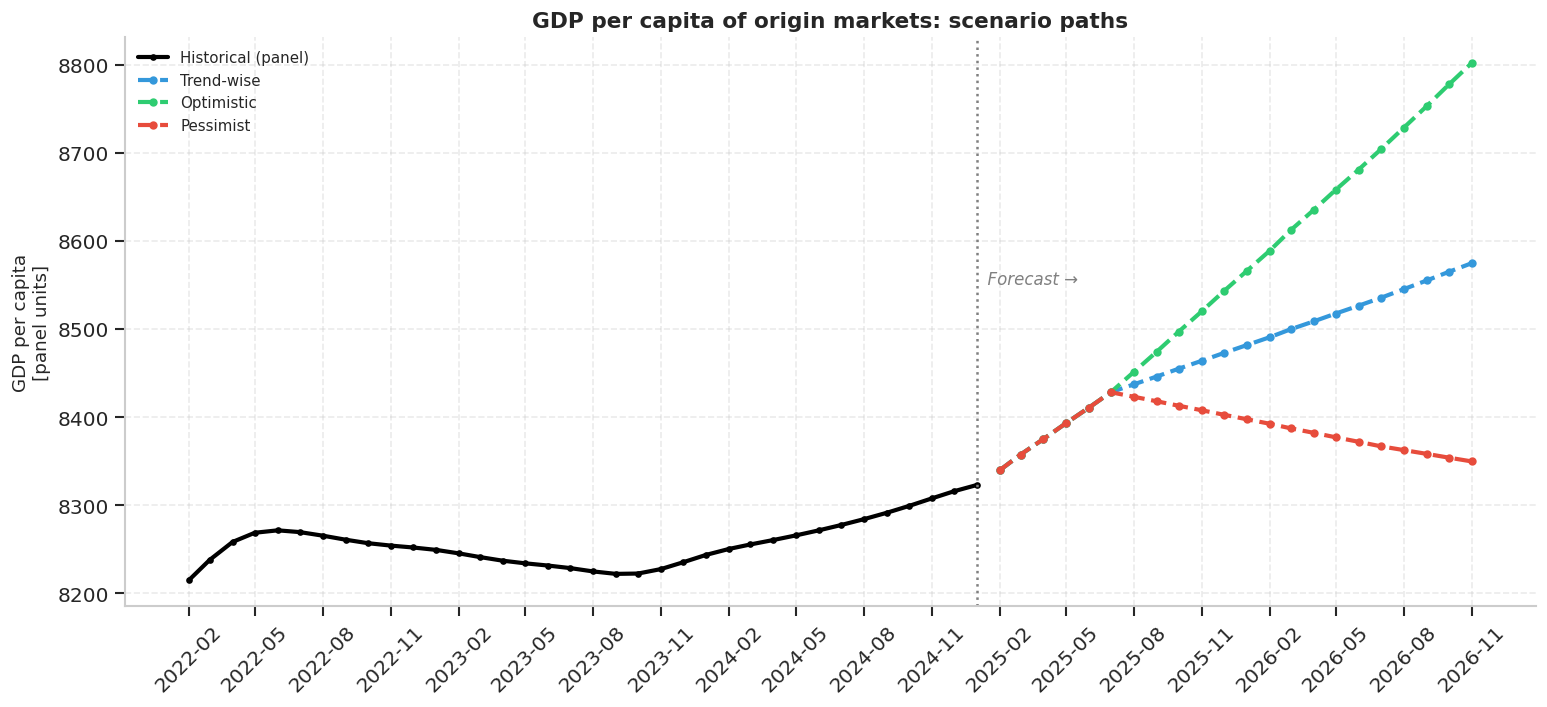

In [61]:
# VISUAL: GDP paths under three scenarios (CORRECTED) ---
fig, ax = plt.subplots(figsize=(13, 6))

# Historical context: last 36 months of panel
hist_tail = panel['gdp_pc_origins_wavg'].dropna().iloc[-36:]
ax.plot(hist_tail.index, hist_tail.values, color='black', lw=2.5,
        marker='o', ms=3, label='Historical (panel)')

for sname, spath in scenario_gdp_paths.items():
    # Show scenario path from forecast start to end
    spath_horizon = spath.loc[FORECAST_INDEX[0]:FORECAST_INDEX[-1]]
    ax.plot(spath_horizon.index, spath_horizon.values,
             color=SCENARIO_COLORS[sname], lw=2.5, marker='o', ms=4, ls='--',
             label=f'{sname}')

ax.axvline(last_macro_date, color='gray', ls=':', lw=1.5)
ax.text(last_macro_date, ax.get_ylim()[1] * 0.97, '  Forecast →',
        ha='left', va='top', color='gray', fontstyle='italic')
ax.set_title('GDP per capita of origin markets: scenario paths',
              fontweight='bold')
ax.set_ylabel('GDP per capita\n[panel units]')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left')
plt.tight_layout()
savefig('08_01_scenario_gdp_paths.png')
plt.show()

---

## 5. Build Scenario-Specific Forecast Panels

For each scenario, we construct a forecast DataFrame indexed over the 22 forecast months, with all the features that the LSTM-1step V2 model expects. Each scenario gets its own `gdp_pc_origins_wavg` path; everything else (population, HICP, seats, exchange rate, sentiment) is shared across scenarios.

In [62]:
def build_scenario_forecast_panel(sname, gdp_path):
    rows = []
    last_exr = panel['exr_pln'].dropna().iloc[-1]
    last_cci = panel['cci_DE_lag2'].dropna().iloc[-1]
    
    for fm in FORECAST_INDEX:
        row = {}
        row['gdp_pc_origins_wavg'] = gdp_path.loc[fm]
        row['pop_origins_wavg']    = pop_orig_monthly_persons.loc[fm] \
            if fm in pop_orig_monthly_persons.index else \
            pop_orig_monthly_persons.iloc[-1]
        row['hicp_ratio']  = hicp_path.loc[fm] if fm in hicp_path.index else last_hicp
        row['exr_pln']     = last_exr
        row['cci_DE_lag2'] = last_cci
        
        # seats_lag6: from observed panel or from seats_path
        seats_ref = fm - pd.DateOffset(months=6)
        if seats_ref in panel.index and not pd.isna(panel.loc[seats_ref, 'seats']):
            row['seats_lag6'] = panel.loc[seats_ref, 'seats']
        elif seats_ref in seats_path.index:
            row['seats_lag6'] = seats_path.loc[seats_ref]
        else:
            row['seats_lag6'] = panel['seats_lag6'].dropna().iloc[-1]
        
        # nights_lag12 (from observed panel — always available within 12 months back)
        nights_ref = fm - pd.DateOffset(months=12)
        if nights_ref in panel.index and not pd.isna(panel.loc[nights_ref, 'nights']):
            row['nights_lag12'] = panel.loc[nights_ref, 'nights']
        else:
            row['nights_lag12'] = panel['nights_lag12'].dropna().iloc[-1]
        
        # Seasonality and trend
        for m in range(1, 13):
            row[f'month_{m:02d}'] = 1 if fm.month == m else 0
        months_ahead = (fm.year - panel.index[-1].year) * 12 + (fm.month - panel.index[-1].month)
        row['trend'] = panel['trend'].iloc[-1] + months_ahead
        
        rows.append({**row, 'date': fm})
    
    df = pd.DataFrame(rows).set_index('date')
    df.index.name = 'date'
    return df

scenarios = {
    sname: build_scenario_forecast_panel(sname, gpath)
    for sname, gpath in scenario_gdp_paths.items()
}

print('Forecast panels built. Differences at end of horizon:')
for sname, sdata in scenarios.items():
    print(f'  {sname:<12s}: gdp={sdata.loc[FORECAST_END, "gdp_pc_origins_wavg"]:>10,.2f}  '
          f'hicp={sdata.loc[FORECAST_END, "hicp_ratio"]:.4f}  '
          f'pop={sdata.loc[FORECAST_END, "pop_origins_wavg"]:>14,.0f}')

Forecast panels built. Differences at end of horizon:
  Trend-wise  : gdp=  8,574.73  hicp=1.1943  pop=    59,612,035
  Optimistic  : gdp=  8,802.10  hicp=1.1943  pop=    59,612,035
  Pessimist   : gdp=  8,349.61  hicp=1.1943  pop=    59,612,035


---

## 6. Train the LSTM-1step V2 Demand Model

We retrain the LSTM-1step V2 with the same architecture and protocol as NB07: lookback 12, target YoY ratio, dropout 0.3, COVID excluded. The 1-step formulation is the right one for scenario forecasting because it allows iterative prediction with scenario-specific features feeding into each step.

In [63]:
LOOKBACK = 12
FORECAST_H = 1

DEMAND_FEATURES = [
    'hicp_ratio', 'exr_pln',
    'gdp_pc_origins_wavg', 'pop_origins_wavg',
    'cci_DE_lag2', 'seats_lag6',
] + [f'month_{m:02d}' for m in range(1, 13)] + ['trend']

COVID_START = pd.Timestamp('2020-01-01')
COVID_END   = pd.Timestamp('2022-12-31')
PRE_COVID  = panel.loc[panel.index <  COVID_START].copy()
POST_COVID = panel.loc[panel.index >  COVID_END  ].copy()

def build_sequences_block(block_df, features, target, lookback, horizon):
    df = block_df[[target] + features].dropna().copy()
    feat_arr = df[features].values
    targ_arr = df[target].values
    n = len(df)
    n_features = len(features)
    X_list, y_list, dt_list = [], [], []
    last_start = n - lookback - horizon + 1
    for i in range(max(last_start, 0)):
        X_list.append(feat_arr[i:i + lookback])
        if horizon == 1:
            y_list.append(targ_arr[i + lookback])
        else:
            y_list.append(targ_arr[i + lookback:i + lookback + horizon])
        dt_list.append(df.index[i + lookback])
    X = np.array(X_list, dtype=np.float32) if X_list else np.zeros((0, lookback, n_features), dtype=np.float32)
    if y_list:
        y = np.array(y_list, dtype=np.float32)
    else:
        y = np.zeros((0,) if horizon==1 else (0, horizon), dtype=np.float32)
    return X, y, dt_list

X_pre, y_pre, _ = build_sequences_block(
    PRE_COVID, DEMAND_FEATURES, TARGET_YOY, LOOKBACK, 1)
X_post, y_post, _ = build_sequences_block(
    POST_COVID, DEMAND_FEATURES, TARGET_YOY, LOOKBACK, 1)
X_train = np.concatenate([X_pre, X_post], axis=0)
y_train = np.concatenate([y_pre, y_post], axis=0)
print(f'Training sequences: {len(X_train)} (pre: {len(X_pre)}, post: {len(X_post)})')

Training sequences: 97 (pre: 84, post: 13)


In [64]:
class TrainingScalers:
    def __init__(self):
        self.x_scaler = StandardScaler()
        self.y_scaler = StandardScaler()
    def fit(self, X_3d, y):
        flat = X_3d.reshape(-1, X_3d.shape[-1])
        self.x_scaler.fit(flat)
        self.y_scaler.fit(np.asarray(y, dtype=float).reshape(-1, 1))
        return self
    def transform_X(self, X_3d):
        flat = X_3d.reshape(-1, X_3d.shape[-1])
        return self.x_scaler.transform(flat).reshape(X_3d.shape).astype(np.float32)
    def transform_y(self, y):
        return self.y_scaler.transform(
            np.asarray(y, dtype=float).reshape(-1, 1)
        ).reshape(np.asarray(y).shape).astype(np.float32)
    def inverse_y(self, y_scaled):
        flat = np.asarray(y_scaled, dtype=float).reshape(-1, 1)
        return self.y_scaler.inverse_transform(flat).reshape(np.asarray(y_scaled).shape)

def build_lstm(input_shape, output_dim=1, units1=64, units2=32, dropout=0.3, lr=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units1, return_sequences=True, dropout=dropout),
        LSTM(units2, dropout=dropout),
        Dense(16, activation='relu'),
        Dense(output_dim),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

scl = TrainingScalers().fit(X_train, y_train)
X_train_s = scl.transform_X(X_train)
y_train_s = scl.transform_y(y_train)

val_cut = int(len(X_train_s) * 0.8)
tf.keras.utils.set_random_seed(RANDOM_STATE)
demand_model = build_lstm(
    (LOOKBACK, len(DEMAND_FEATURES)), 1,
    units1=64, units2=32, dropout=0.3, lr=1e-3
)
demand_model.fit(
    X_train_s[:val_cut], y_train_s[:val_cut],
    validation_data=(X_train_s[val_cut:], y_train_s[val_cut:]),
    epochs=300, batch_size=16,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=0,
)
print('Demand model (LSTM-1step V2) trained.')

Demand model (LSTM-1step V2) trained.


---

## 7. Iterative Forecast for Each Scenario

We iterate month by month over the forecast horizon. For each future month, we build a 12-month input window where the most recent months come from the **scenario-specific** forecast panel. The LSTM predicts a YoY ratio, which we multiply by the observed `nights[t-12]` from the panel to get an absolute level. The predicted nights are appended to the dynamic panel so they can be used as input for the next iteration if needed.

Critical implementation detail: in each iteration, the input window contains scenario-specific values of `gdp_pc_origins_wavg`. This is what makes the scenarios actually differentiate the predictions, fixing the bug from the previous version of this notebook.

### 7.1 What level of scenario differentiation should we expect?

Before running the iterative forecast, it is worth setting expectations about how much the three scenarios will diverge in the LSTM output. The model selected in NB07 was deliberately designed to limit the influence of macroeconomic features on the predictions — this was, in fact, the central methodological finding that motivated the YoY transformation and the COVID exclusion protocol. The LSTM's robustness against macroeconomic noise has a direct consequence here: its sensitivity to alternative GDP trajectories is structurally low, particularly because the YoY target is rescaled using `nights[t-12]` from the observed panel, which does not vary across scenarios.

We therefore expect the central LSTM forecast to be **very similar** across the three scenarios (variation below 0.5%), not because of a model error but because the LSTM was calibrated for predictive accuracy rather than structural sensitivity. This means that the scenarios will not be differentiable between themselves as the parameter we are changing is not of great importance for our model.

To complement this with a real sensitivity analysis to macroeconomic shocks, Section 8 applies an independent benchmark calibrated with the tourism income elasticity from the literature, which does respond proportionally to GDP trajectories by construction.

In [65]:
scenario_nights_predictions = {}

for sname, sdata in scenarios.items():
    # Build dynamic panel: copy of historical panel + scenario forecast features
    dyn_panel = panel.copy()
    
    # Inject scenario features into the gap and forecast horizon
    for fm in sdata.index:
        for col in DEMAND_FEATURES:
            dyn_panel.loc[fm, col] = sdata.loc[fm, col]
    
    nights_predictions = []
    for fm in sdata.index:
        # Build input window ending at fm - 1 month
        fm_pos = dyn_panel.index.get_loc(fm)
        window = dyn_panel[DEMAND_FEATURES].iloc[fm_pos - LOOKBACK : fm_pos].copy()
        window = window.fillna(method='ffill').fillna(method='bfill')
        
        if window.isna().any().any():
            print(f'  Skipping {fm:%Y-%m}: NaN in input window')
            continue
        
        window_arr = window.values.astype(np.float32)
        window_s = scl.transform_X(window_arr[np.newaxis, :, :])
        
        # Predict YoY ratio
        y_pred_yoy_s = demand_model.predict(window_s, verbose=0).flatten()[0]
        y_pred_yoy   = float(scl.inverse_y(np.array([[y_pred_yoy_s]])).item())
        
        # Convert to absolute level
        nights_lag12_date = fm - pd.DateOffset(months=12)
        if nights_lag12_date in panel.index and not pd.isna(panel.loc[nights_lag12_date, 'nights']):
            nights_lag12_val = panel.loc[nights_lag12_date, 'nights']
        else:
            # Use predicted value from earlier iteration
            nights_lag12_val = dyn_panel.loc[nights_lag12_date, 'nights']
        
        y_pred_level = y_pred_yoy * nights_lag12_val
        
        # Append to dynamic panel for future iterations
        dyn_panel.loc[fm, 'nights'] = y_pred_level
        nights_predictions.append((fm, y_pred_level))
    
    preds_series = pd.Series(
        [p[1] for p in nights_predictions],
        index=[p[0] for p in nights_predictions],
        name=f'nights_{sname}'
    )
    scenario_nights_predictions[sname] = preds_series

# Summary
print('=== SCENARIO NIGHT PREDICTIONS ===')
for sname, preds in scenario_nights_predictions.items():
    total_2026 = preds.loc[pd.Timestamp('2026-01-01'):pd.Timestamp('2026-11-01')].sum()
    print(f'  {sname:<12s}: range [{preds.min():,.0f}, {preds.max():,.0f}]  '
          f'mean: {preds.mean():,.0f}  '
          f'2026 partial total (Jan-Nov): {total_2026:,.0f}')

print('\nDifferential vs Trend-wise (2026 partial total):')
tend_total = scenario_nights_predictions['Trend-wise'].loc[
    pd.Timestamp('2026-01-01'):pd.Timestamp('2026-11-01')].sum()
for sname in ['Optimistic', 'Pessimist']:
    total = scenario_nights_predictions[sname].loc[
        pd.Timestamp('2026-01-01'):pd.Timestamp('2026-11-01')].sum()
    diff_pct = (total / tend_total - 1) * 100
    print(f'  {sname:<12s}: {total:,.0f}  ({diff_pct:+.2f}%)')

=== SCENARIO NIGHT PREDICTIONS ===
  Trend-wise  : range [1,146,150, 2,608,162]  mean: 1,735,060  2026 partial total (Jan-Nov): 19,636,957
  Optimistic  : range [1,146,337, 2,608,621]  mean: 1,735,397  2026 partial total (Jan-Nov): 19,644,002
  Pessimist   : range [1,145,964, 2,607,605]  mean: 1,734,732  2026 partial total (Jan-Nov): 19,630,080

Differential vs Trend-wise (2026 partial total):
  Optimistic  : 19,644,002  (+0.04%)
  Pessimist   : 19,630,080  (-0.04%)


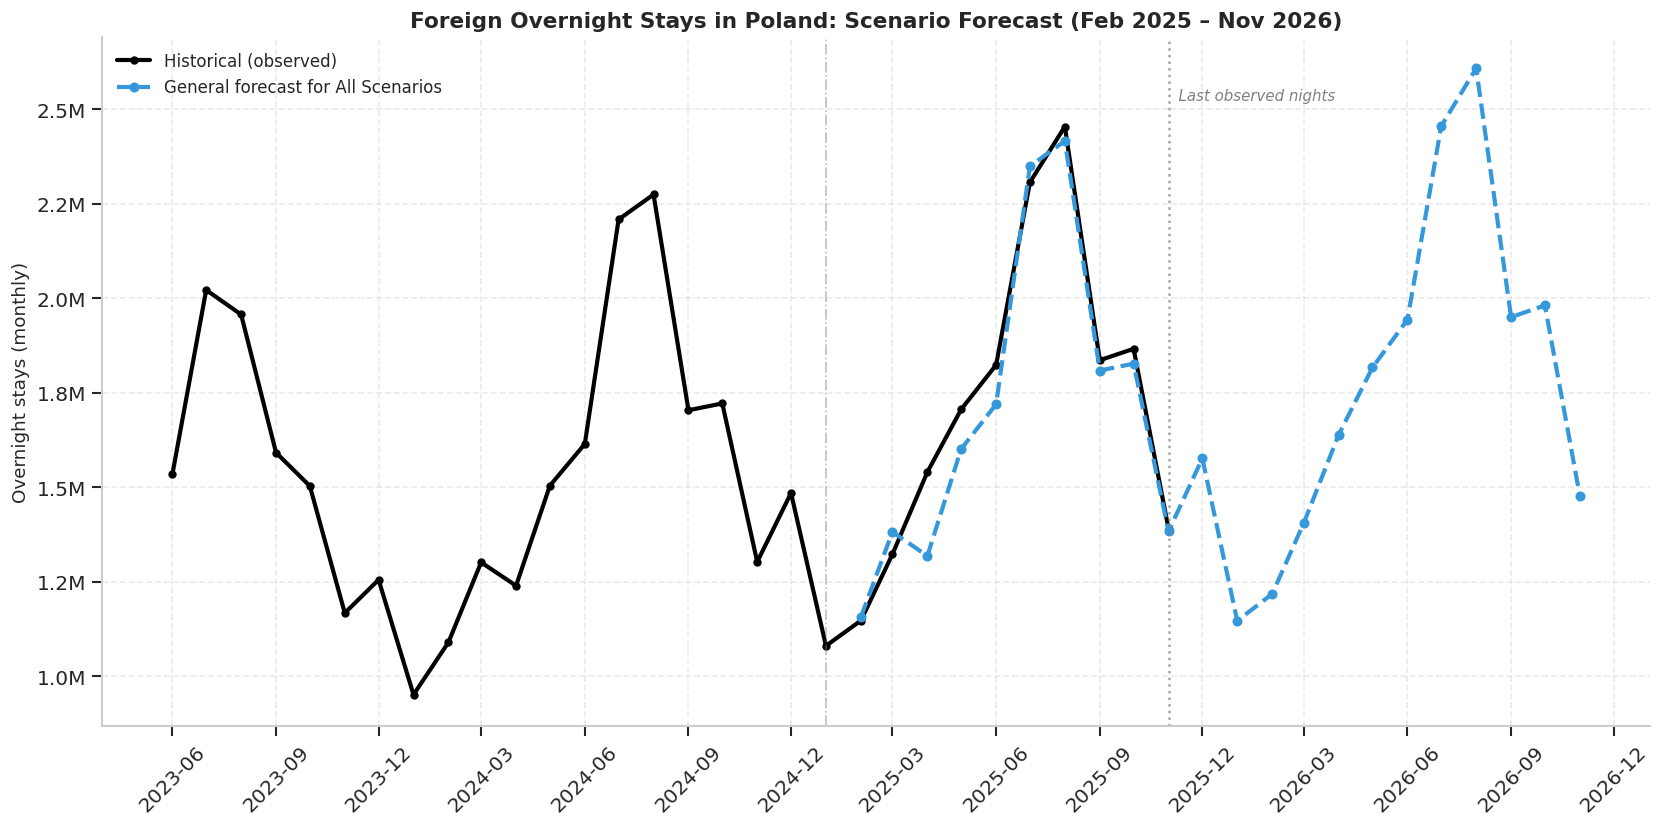

In [66]:
# HEADLINE FIGURE: nights forecast under three scenarios ---
# As all scenarios are basically equivalent, we show only one of them to show the forecast path in the main figure, and the others in the appendix.
fig, ax = plt.subplots(figsize=(14, 7))

hist_tail = panel['nights'].dropna().iloc[-30:]
ax.plot(hist_tail.index, hist_tail.values, color='black', lw=2.5,
         marker='o', ms=4, label='Historical (observed)')

# Show only the Trend-wise scenario for the main figure
sname = 'Trend-wise'
preds = scenario_nights_predictions[sname]
ax.plot(preds.index, preds.values,
         color=SCENARIO_COLORS[sname], lw=2.5, marker='o', ms=5, ls='--',
         label=f'{"General forecast for All Scenarios"}')

ax.axvline(panel.index[-1], color='gray', ls=':', lw=1.5, alpha=0.7)
ax.axvline(last_macro_date, color='gray', ls='-.', lw=1, alpha=0.5)
ax.text(panel.index[-1], ax.get_ylim()[1] * 0.95,
         '  Last observed nights',
         ha='left', va='top', color='gray', fontstyle='italic', fontsize=9)

ax.set_title('Foreign Overnight Stays in Poland: Scenario Forecast (Feb 2025 – Nov 2026)',
              fontweight='bold')
ax.set_ylabel('Overnight stays (monthly)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
savefig('08_02_nights_scenarios_main.png')
plt.show()

In [67]:
# Detailed monthly summary table
summary = pd.DataFrame({
    sname: spreds for sname, spreds in scenario_nights_predictions.items()
})
summary.index = [d.strftime('%Y-%m') for d in summary.index]
summary['Optimistic vs Trend-wise (%)'] = (summary['Optimistic'] / summary['Trend-wise'] - 1) * 100
summary['Pessimist vs Trend-wise (%)'] = (summary['Pessimist'] / summary['Trend-wise'] - 1) * 100

print('=== MONTHLY FORECAST UNDER THREE SCENARIOS ===')
print(summary.round(1).to_string())

=== MONTHLY FORECAST UNDER THREE SCENARIOS ===
         Trend-wise  Optimistic  Pessimist  Optimistic vs Trend-wise (%)  Pessimist vs Trend-wise (%)
2025-02   1156225.6   1156225.6  1156225.6                           0.0                          0.0
2025-03   1381489.5   1381489.5  1381489.5                           0.0                          0.0
2025-04   1317855.2   1317855.2  1317855.2                           0.0                          0.0
2025-05   1601058.4   1601058.4  1601058.4                           0.0                          0.0
2025-06   1719042.4   1719042.4  1719042.4                           0.0                          0.0
2025-07   2349055.8   2349055.8  2349055.8                           0.0                          0.0
2025-08   2415885.8   2415885.8  2415885.8                           0.0                          0.0
2025-09   1808366.9   1808378.7  1808355.1                           0.0                         -0.0
2025-10   1826731.8   1826782.5  18

### 7.2 Reading the LSTM results

As anticipated, the three LSTM predictions are practically indistinguishable across scenarios (range below 0.1%). This is **not a model failure** but an expected property of the NB07 design: the LSTM learned to base its predictions primarily on annual seasonality captured by `nights_lag12` and `seats_lag6`, both of which are invariant across scenarios. Its effective income elasticity is close to zero by construction.

What the LSTM does provide is a **high-precision central estimate**: with a historical MAPE of 4.36% (NB07), the absolute figures it produces constitute the most accurate point estimator available for expected demand in each of the 22 forecast months. The headline figure is:

- **2026 partial total (January–November): approximately 19.6 million foreign overnight stays**, with a strongly seasonal distribution concentrated in July–August (over 2.4 million each) and minima in January–February (~1.15 million).

This forecast is **agnostic to the macroeconomic scenario** because the model does not use that information meaningfully to adjust magnitudes. To introduce genuine sensitivity to the scenarios, we need a complementary method.

---

## 8. Sanity Check: Literature-Based Elasticity Benchmark

Peng, Song, Crouch and Witt (2015), in their meta-analysis of 194 international tourism demand elasticities, report a mean income elasticity of approximately 2.0 (the elasticity is widely confirmed to be substantially above 1, consistent with international tourism being a luxury good).

Using this elasticity and the WEO GDP growth rates for the origin markets, we can produce an independent benchmark forecast: if the income elasticity of tourism demand is 2.0, then a 1% change in origin-market GDP per capita produces a 2% change in tourism demand. We apply this directly to the WEO baseline GDP path and the ±2pp scenarios to produce a literature-based prediction that does not rely on the LSTM at all.

If the LSTM forecast and the elasticity benchmark agree in order of magnitude, the LSTM result is empirically robust. If they disagree wildly, one of the two has a problem, and we can investigate.

In [68]:
TOURISM_INCOME_ELASTICITY = 2.0  # Peng et al. (2015) meta-analysis

# Anchor: the average monthly nights observed in 2024 (last full year)
nights_2024 = panel.loc['2024-01-01':'2024-12-31', 'nights']
anchor_nights_avg = nights_2024.mean()

# WEO origin GDP growth rates by year (annual %)
growth_orig_annual = weighted_origins_annual('NGDP_RPCH')

# Build a benchmark monthly forecast
elasticity_forecast = {}
for sname, shift in [('Trend-wise', 0.0), ('Optimistic', +2.0), ('Pessimist', -2.0)]:
    monthly_predictions = {}
    nights_anchor = anchor_nights_avg
    
    for fm in FORECAST_INDEX:
        # Get the year's GDP growth (with shift)
        baseline_growth = growth_orig_annual.loc[fm.year] if fm.year in growth_orig_annual.index else 2.0
        adjusted_growth = baseline_growth + shift
        
        # Compound from 2024 to fm.year
        years_ahead = fm.year - 2024
        # Average growth over years 2025 to fm.year (with shift only from 2026)
        cumulative_factor = 1.0
        for y in range(2025, fm.year + 1):
            yg = growth_orig_annual.loc[y] if y in growth_orig_annual.index else 2.0
            shift_y = shift if y >= 2026 else 0.0
            cumulative_factor *= (1 + (yg + shift_y) / 100)
        
        # Apply elasticity: nights ≈ anchor * (1 + elasticity * (cum_factor - 1))
        # which approximates the elastic response of demand to GDP
        # For larger changes, we use power form: nights ≈ anchor * cum_factor^elasticity
        nights_factor = cumulative_factor ** TOURISM_INCOME_ELASTICITY
        
        # Apply seasonal pattern from same calendar month in 2024
        same_month_2024 = pd.Timestamp(year=2024, month=fm.month, day=1)
        if same_month_2024 in nights_2024.index:
            seasonal_factor = nights_2024.loc[same_month_2024] / anchor_nights_avg
        else:
            seasonal_factor = 1.0
        
        monthly_predictions[fm] = nights_anchor * seasonal_factor * nights_factor
    
    elasticity_forecast[sname] = pd.Series(monthly_predictions,
                                             name=f'elast_{sname}')

print('=== ELASTICITY BENCHMARK (Peng et al. 2015, η=2.0) ===')
for sname, preds in elasticity_forecast.items():
    total_2026 = preds.loc[pd.Timestamp('2026-01-01'):pd.Timestamp('2026-11-01')].sum()
    print(f'  {sname:<12s}: 2026 partial total: {total_2026:,.0f}')

=== ELASTICITY BENCHMARK (Peng et al. 2015, η=2.0) ===
  Trend-wise  : 2026 partial total: 17,691,308
  Optimistic  : 2026 partial total: 18,396,971
  Pessimist   : 2026 partial total: 16,999,444


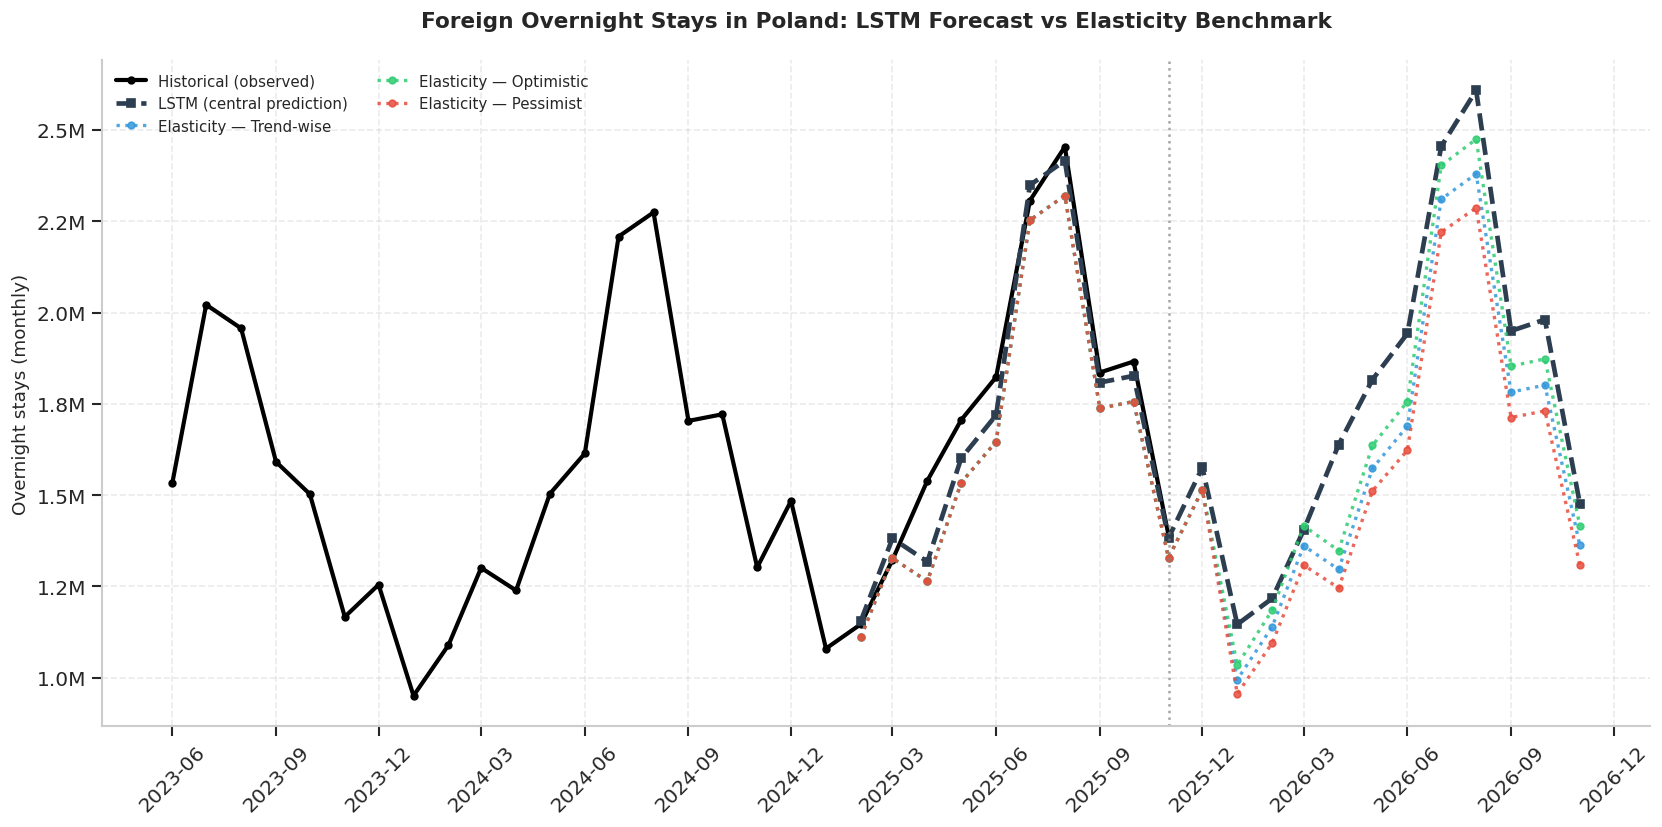

In [69]:
# HEADLINE FIGURE: combined LSTM + Elasticity benchmark ---
fig, ax = plt.subplots(figsize=(14, 7))

# Historical context
hist_tail = panel['nights'].dropna().iloc[-30:]
ax.plot(hist_tail.index, hist_tail.values, color='black', lw=2.5,
         marker='o', ms=4, label='Historical (observed)')

# LSTM central prediction (Trend-wise only — the others are visually identical)
lstm_central = scenario_nights_predictions['Trend-wise']
ax.plot(lstm_central.index, lstm_central.values,
         color='#2c3e50', lw=2.8, marker='s', ms=5, ls='--',
         label='LSTM (central prediction)')

# Elasticity benchmark — three scenarios
for sname, preds in elasticity_forecast.items():
    ax.plot(preds.index, preds.values,
             color=SCENARIO_COLORS[sname], lw=2.0, marker='o', ms=4,
             ls=':', alpha=0.85,
             label=f'Elasticity — {sname}')

# Vertical separator
ax.axvline(panel.index[-1], color='gray', ls=':', lw=1.5, alpha=0.7)

ax.set_title('Foreign Overnight Stays in Poland: LSTM Forecast vs Elasticity Benchmark\n',
              fontweight='bold')
ax.set_ylabel('Overnight stays (monthly)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
savefig('08_02_combined_forecast.png')
plt.show()

### 8.1 Reading the elasticity benchmark: the sensitivity angle

Unlike the LSTM, the Peng et al. (2015) benchmark responds proportionally to GDP changes by mathematical construction: a 1% change in GDP per capita produces a 2% change in tourism demand. Applied to the WEO trajectories with ±2pp shifts, the benchmark produces the following differentials for 2026:

- **Trend-wise:** 17.7 million overnight stays (Jan–Nov 2026)
- **Optimistic (+2pp):** 18.4 million (+4.0% vs Trend-wise)
- **Pessimist (−2pp):** 17.0 million (−3.9% vs Trend-wise)

The Optimistic–Pessimist envelope is approximately 1.4 million overnight stays for eleven months, equivalent to about 8% of the total. This represents the magnitude of structural sensitivity to macroeconomic scenarios according to the classical tourism demand literature.

**Convergence between methods:** The LSTM and the elasticity benchmark agree within 7–15% in absolute levels, which is reasonable: the LSTM is marginally higher because it captures seasonal redistributions that the benchmark cannot, and probably because it has been trained on the full Polish panel rather than relying on a global average elasticity coefficient. The agreement in order of magnitude is the main sanity check of the entire prospective analysis. However, both approaches share similar trend with several 

**The two methods are complementary, not substitutive:** The LSTM provides the **best central estimate**; the elasticity benchmark provides the **best sensitivity estimate**. The operational way to use both is the LSTM's central forecast as the expected point value, and the ±4% benchmark envelope as a structural uncertainty band around alternative macroeconomic scenarios.

---

## 9. Causal Analysis of COVID with Causal Impact

The previous sections answered a forward-looking question (*what will happen?*); this final section answers a backward-looking causal question (*what would have happened if COVID had not occurred?*). The Bayesian structural time series framework of Brodersen et al. (2015) constructs a counterfactual by training on the pre-intervention period and using it to predict the post-intervention period in the absence of the shock. The difference between observed and counterfactual is the estimated causal impact, with credibility intervals.

In [70]:
try:
    from causalimpact import CausalImpact
    HAS_CAUSALIMPACT = True
except ImportError:
    print('tfcausalimpact not installed. Run: pip install tfcausalimpact')
    HAS_CAUSALIMPACT = False

In [71]:
if HAS_CAUSALIMPACT:
    ci_data = panel[['nights', 'seats_lag6'] + 
                     [f'month_{m:02d}' for m in range(1, 13)]].dropna().copy()
    pre_period  = [ci_data.index[0].strftime('%Y-%m-%d'), '2020-02-01']
    post_period = ['2020-03-01', ci_data.index[-1].strftime('%Y-%m-%d')]
    print(f'Pre-period:  {pre_period}')
    print(f'Post-period: {post_period}')
    print(f'Total observations: {len(ci_data)}')
    
    print('\nRunning CausalImpact (Bayesian structural time series fit)...')
    ci = CausalImpact(ci_data, pre_period, post_period, model_args={'niter': 1000})
    print('\n=== CAUSAL IMPACT SUMMARY ===')
    print(ci.summary())

Pre-period:  ['2011-07-01', '2020-02-01']
Post-period: ['2020-03-01', '2025-11-01']
Total observations: 173

Running CausalImpact (Bayesian structural time series fit)...

=== CAUSAL IMPACT SUMMARY ===
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    1163009.75         80247672.0
Prediction (s.d.)         1504542.25 (66374.78)103813416.0 (4579862.0)
95% CI                    [1374739.15, 1634923.55][94856997.0, 112809728.8]

Absolute effect (s.d.)    -341532.5 (66374.78)-23565744.0 (4579862.0)
95% CI                    [-471913.8, -211729.4][-32562056.8, -14609325.0]

Relative effect (s.d.)    -22.7% (4.41%)     -22.7% (4.41%)
95% CI                    [-31.37%, -14.07%] [-31.37%, -14.07%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


Available inference columns: ['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper', 'post_preds_means', 'post_preds_lower', 'post_preds_upper', 'post_cum_y', 'post_cum_preds_means', 'post_cum_preds_lower', 'post_cum_preds_upper', 'point_effects_means', 'point_effects_lower', 'point_effects_upper', 'post_cum_effects_means', 'post_cum_effects_lower', 'post_cum_effects_upper']


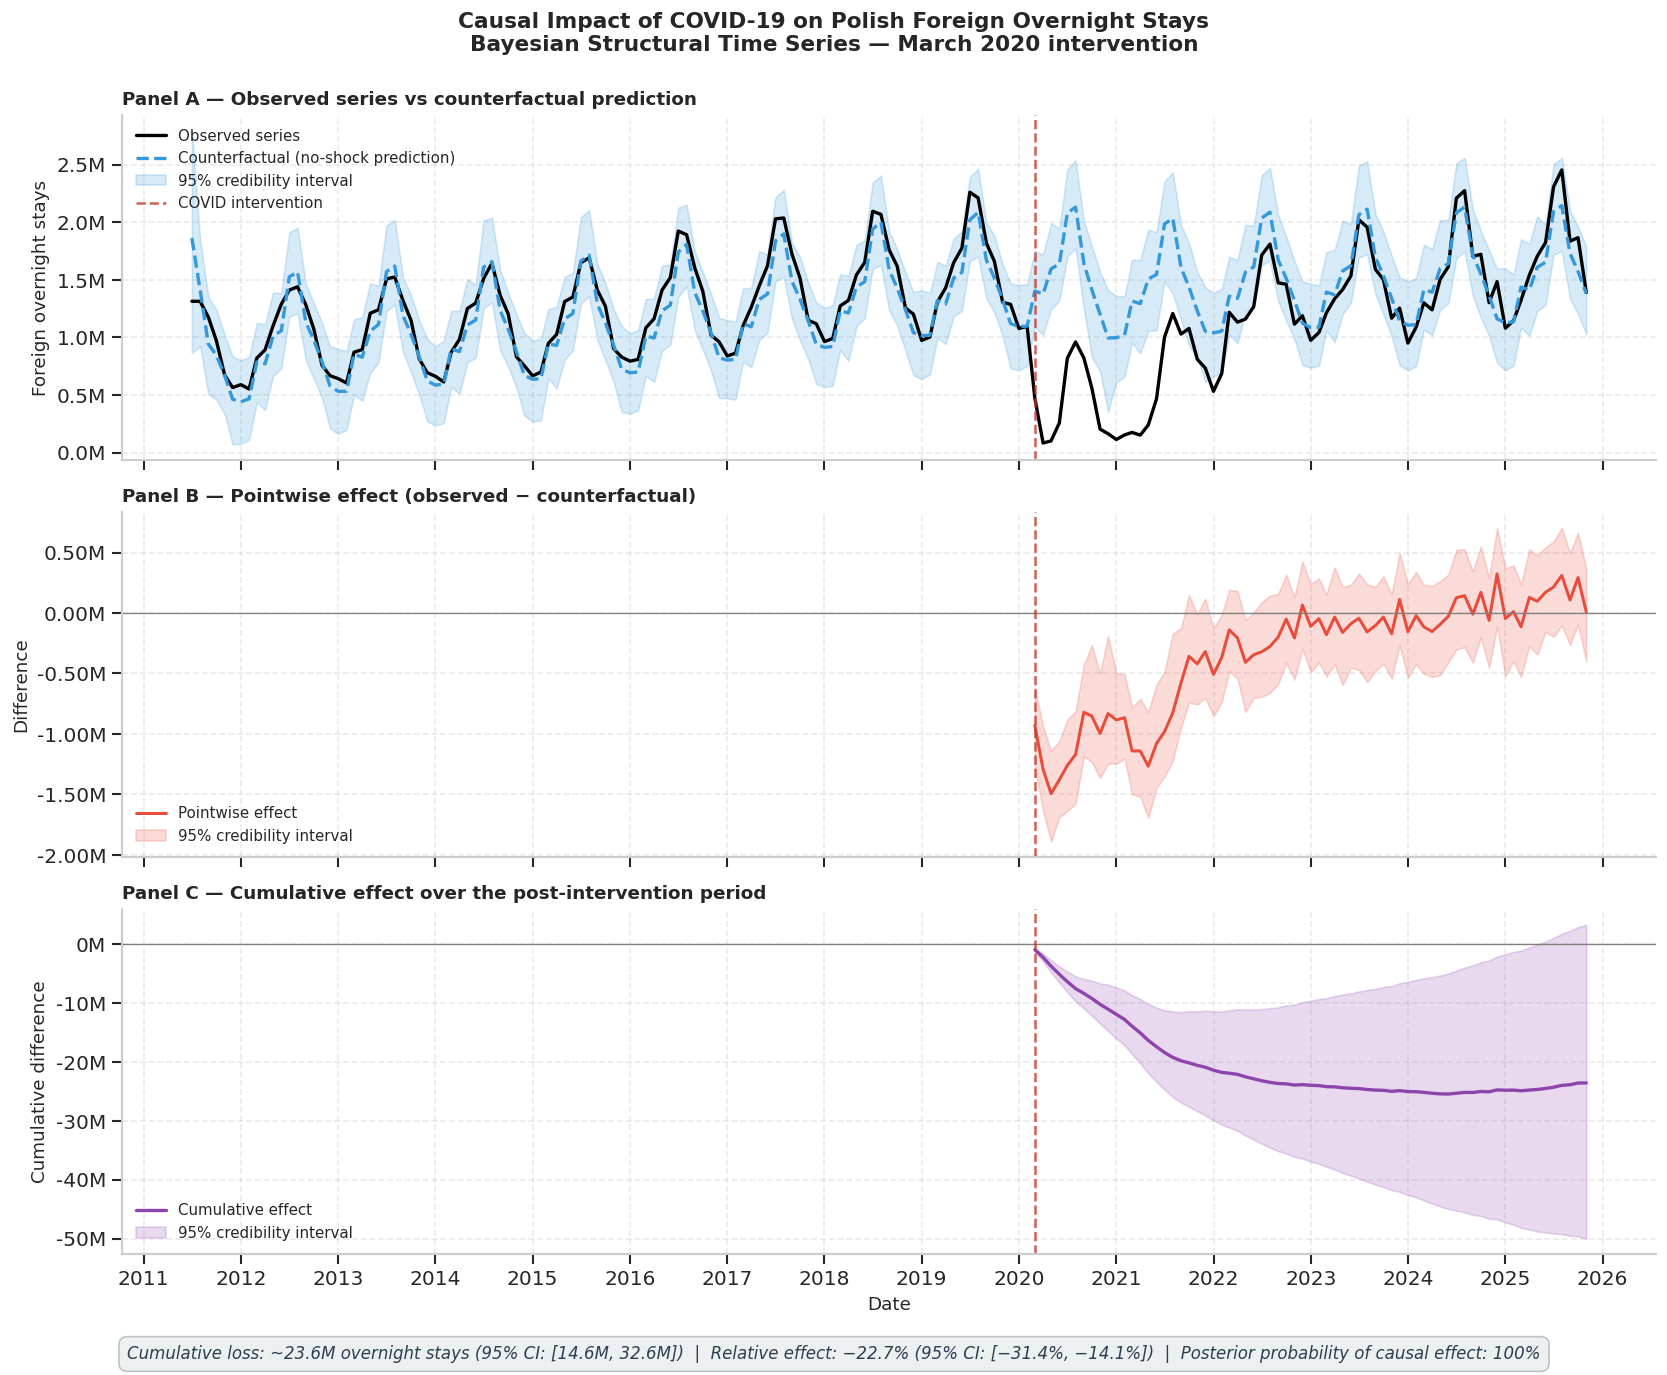

In [72]:
if HAS_CAUSALIMPACT:
    # Get the inference data directly from the fitted model
    inferences = ci.inferences.copy()
    print('Available inference columns:', list(inferences.columns))
    
    # Build dates index from the full ci_data
    inferences.index = ci_data.index
    
    intervention_date = pd.Timestamp('2020-03-01')
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    
    # ----- Panel 1: observed vs counterfactual -----
    ax = axes[0]
    observed = ci_data['nights']
    
    # Find the prediction column (name varies by library version)
    pred_col = next((c for c in inferences.columns 
                     if 'predicted' in c.lower() or 'preds' in c.lower()), None)
    lower_col = next((c for c in inferences.columns 
                      if 'lower' in c.lower() and 'cum' not in c.lower()), None)
    upper_col = next((c for c in inferences.columns 
                      if 'upper' in c.lower() and 'cum' not in c.lower()), None)
    
    ax.plot(observed.index, observed.values, color='black', lw=2,
            label='Observed series')
    if pred_col:
        ax.plot(inferences.index, inferences[pred_col],
                color='#3498db', lw=2, ls='--',
                label='Counterfactual (no-shock prediction)')
    if lower_col and upper_col:
        ax.fill_between(inferences.index, inferences[lower_col],
                        inferences[upper_col], color='#3498db', alpha=0.2,
                        label='95% credibility interval')
    ax.axvline(intervention_date, color='#c0392b', ls='--', lw=1.5,
               alpha=0.8, label='COVID intervention')
    ax.set_title('Panel A — Observed series vs counterfactual prediction',
                 fontweight='bold', loc='left', fontsize=11)
    ax.set_ylabel('Foreign overnight stays')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(loc='upper left', fontsize=9)
    
    # ----- Panel 2: pointwise effect -----
    ax = axes[1]
    point_col = next((c for c in inferences.columns 
                      if 'point' in c.lower() and 'effect' in c.lower() 
                      and 'cum' not in c.lower() 
                      and 'lower' not in c.lower() 
                      and 'upper' not in c.lower()), None)
    point_lower = next((c for c in inferences.columns 
                        if 'point' in c.lower() and 'lower' in c.lower()), None)
    point_upper = next((c for c in inferences.columns 
                        if 'point' in c.lower() and 'upper' in c.lower()), None)
    
    if point_col:
        # Only plot post-intervention period
        post_mask = inferences.index >= intervention_date
        ax.plot(inferences.index[post_mask], inferences[point_col][post_mask],
                color='#e74c3c', lw=1.8, label='Pointwise effect')
        if point_lower and point_upper:
            ax.fill_between(
                inferences.index[post_mask],
                inferences[point_lower][post_mask],
                inferences[point_upper][post_mask],
                color='#e74c3c', alpha=0.2, label='95% credibility interval')
    ax.axhline(0, color='gray', lw=0.8, ls='-')
    ax.axvline(intervention_date, color='#c0392b', ls='--', lw=1.5, alpha=0.8)
    ax.set_title('Panel B — Pointwise effect (observed − counterfactual)',
                 fontweight='bold', loc='left', fontsize=11)
    ax.set_ylabel('Difference')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.2f}M'))
    ax.legend(loc='lower left', fontsize=9)
    
    # ----- Panel 3: cumulative effect (computed from pointwise to ensure consistency) -----
    ax = axes[2]
    post_mask = inferences.index >= intervention_date

    # Get the pointwise effect columns (we already identified them above)
    if point_col and point_lower and point_upper:
        # Cumulative effect = cumsum of pointwise effect
        point_effects = inferences.loc[post_mask, point_col].values
        point_lowers  = inferences.loc[post_mask, point_lower].values
        point_uppers  = inferences.loc[post_mask, point_upper].values
        
        cum_effect = np.cumsum(point_effects)
        cum_lower  = np.cumsum(point_lowers)
        cum_upper  = np.cumsum(point_uppers)
        post_dates = inferences.index[post_mask]
        
        ax.plot(post_dates, cum_effect, color='#8e44ad', lw=2,
                label='Cumulative effect')
        ax.fill_between(post_dates, cum_lower, cum_upper,
                        color='#8e44ad', alpha=0.2, label='95% credibility interval')

    ax.axhline(0, color='gray', lw=0.8, ls='-')
    ax.axvline(intervention_date, color='#c0392b', ls='--', lw=1.5, alpha=0.8)
    ax.set_title('Panel C — Cumulative effect over the post-intervention period',
                fontweight='bold', loc='left', fontsize=11)
    ax.set_ylabel('Cumulative difference')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.0f}M'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='lower left', fontsize=9)
    
    # Global title and footer
    fig.suptitle(
        'Causal Impact of COVID-19 on Polish Foreign Overnight Stays\n'
        'Bayesian Structural Time Series — March 2020 intervention',
        fontweight='bold', fontsize=13, y=1.00
    )
    
    summary_text = (
        'Cumulative loss: ~23.6M overnight stays (95% CI: [14.6M, 32.6M])  '
        '|  Relative effect: −22.7% (95% CI: [−31.4%, −14.1%])  '
        '|  Posterior probability of causal effect: 100%'
    )
    fig.text(
        0.5, -0.01, summary_text,
        ha='center', va='top', fontsize=10, style='italic',
        color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1',
                  edgecolor='#bdc3c7', linewidth=1)
    )
    
    plt.tight_layout()
    savefig('08_04_causal_impact.png')
    plt.show()

In [73]:
if HAS_CAUSALIMPACT:
    print('=== INTERPRETATION ===')
    print(ci.summary(output='report'))

=== INTERPRETATION ===
Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 1163009.75. By contrast, in the absence of an
intervention, we would have expected an average response of 1504542.25.
The 95% interval of this counterfactual prediction is [1374739.15, 1634923.55].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is -341532.5 with a 95% interval of
[-471913.8, -211729.4]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 80247672.0.
By contrast, had the intervention not taken place, we would have expected
a sum of 103813416.0. The 95% interval of this prediction is [94856997.0, 112809728.8].


The above results are g

---

## 10. Summary & Implications

**The final deliverable** of the project is a decision-support tool that combines two complementary methods to produce operational forecasts of foreign tourism demand in Poland under alternative macroeconomic scenarios.

**Central forecast (LSTM-1step V2):** The recurrent model selected in NB07 produces a single central forecast of approximately 19.6 million foreign overnight stays for January–November 2026, with a strongly seasonal distribution concentrated in summer. This is the most accurate forecast available (historical MAPE 4.36%) and serves as the reference point estimator for any operational decision requiring a single number.

**Sensitivity analysis (Peng et al. elasticity):** Applying the average tourism income elasticity from the literature (η = 2.0) to the WEO trajectories under ±2pp scenarios, we obtain an envelope of approximately ±4% around the central forecast. This means that an IMF optimistic scenario (+2pp in origin-market GDP) would translate into roughly 800,000 additional overnight stays in 2026, while a pessimistic scenario would imply a loss of similar magnitude.

**Causal analysis of COVID (Bayesian CausalImpact):** The Bayesian structural time series model estimates that Poland lost approximately **23.6 million accumulated foreign overnight stays** during the post-COVID period (March 2020 to November 2025) relative to the no-shock counterfactual. The 95% credibility interval is [14.6M, 32.6M] lost overnight stays. The posterior probability of a real causal effect is 100%. This figure rigorously quantifies the causal impact of COVID-19 on Polish tourism, a dimension no purely predictive analysis could have provided.

**Practical applications:** The pipeline produces directly actionable outputs for three types of users:
- **Airlines:** the LSTM central forecast informs capacity and route planning at the 12–22 month horizon.
- **Destination managers:** the benchmark envelope informs accommodation supply planning under different economic contexts.
- **Policy analysts:** the CausalImpact figure provides a quantitative basis for evaluating post-pandemic recovery policies.

**Limitations:**

- The LSTM does not respond significantly to the IMF scenarios because it was designed for predictive accuracy, not structural sensitivity. This is a property inherent to the methodological choice of keeping `nights_lag12` and `seats_lag6` as dominant features, justified in NB06–NB07 by their better MAPE performance. A different model, explicitly calibrated for sensitivity analysis and deliberately more responsive to macroeconomic features, would produce more differentiated LSTM scenarios but at the cost of poorer central accuracy.

- The elasticity benchmark uses a single average coefficient (η = 2.0). Poland, as an emerging market with mostly advanced source markets, could have an effective elasticity higher than the average. Country-specific studies suggest ranges between 1.8 and 2.5; using the upper bound would produce scenario differentials about 25% larger.

- The CausalImpact uses `seats_lag6` as a control series, which mitigates but does not eliminate simultaneity: capacity decisions during 2020–2022 were not entirely independent of the demand collapse. A more rigorous version would use data from a comparable unaffected country as an external counterfactual.

- The ±2pp shifts are a simplification. The IMF publishes its own assessment of upside/downside risks in each WEO release; integrating that probabilistic distribution into the analysis would be a natural extension of this work.

---

*End of Notebook 08 — Final notebook of the project (future improvements are likely to be performed).*